# R1 - RSAS - REPRODUCTION

In [3]:
import sentence_transformers
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize
import torch

In [4]:
#load model
model = sentence_transformers.SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

@torch.no_grad()
def extract_embeddings(responses):
    """Transform responses into embeddings using a given embedding model."""
    embeddings = model.encode(responses, convert_to_tensor=True)  # Procesar lista, no string único
    embeddings_np = embeddings.detach().cpu().numpy()# Asegurar que sea 2D
    return np.atleast_2d(embeddings_np)

def normalize_embeddings(embeddings):
    return normalize(embeddings, axis=1)

def calculate_gramian(embeddings):
    """Calculate the Gramian matrix using dot product."""
    #gramian = np.dot(embeddings, embeddings.T)
    gramian = np.matmul(embeddings, embeddings.T)
    return gramian

In [5]:
%cd /mnt/f/robusto/vqa_analysis

/mnt/f/robusto/vqa_analysis


In [17]:
df_r1 = pd.read_csv("data/r1_cleaned.csv", keep_default_na=False)

#remove all rows with [Empty] from the answers
df_r1 = df_r1[df_r1["ANSWER"] != "[Empty]"].reset_index(drop=True)
df_r1 = df_r1[df_r1["QUESTION_NUM"].isin([1, 2, 3,4,5,6,8,10,11,12,13,14,15])].reset_index(drop=True)
df_r1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5480 entries, 0 to 5479
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   AGENT         5480 non-null   str  
 1   VIDEO         5480 non-null   str  
 2   QUESTION_NUM  5480 non-null   int64
 3   QUESTION      5480 non-null   str  
 4   ANSWER        5480 non-null   str  
 5   REPETITION    5480 non-null   int64
 6   BLOCK         5480 non-null   int64
dtypes: int64(3), str(4)
memory usage: 1002.8 KB


In [18]:
#select all the human responses
def is_human_agent(agent):
    return "Humano" in agent

sort_cols = ["VIDEO", "QUESTION_NUM"]  # <- cambia QUESTION_ID por tu columna real
mask_h = df_r1["AGENT"].apply(is_human_agent)
df_r1_humans = df_r1[mask_h]
df_r1_vlms = df_r1[~mask_h]
r = df_r1_humans[df_r1_humans["AGENT"] == "Humano2"]
r

,AGENT,VIDEO,QUESTION_NUM,QUESTION,ANSWER,REPETITION,BLOCK
2844,Humano2,Robusto 1_201,1,Q1: What driving action is taking place?,Going forward and breaking,1,1
2845,Humano2,Robusto 1_201,2,Q2: Is there any interaction with other vehicles?,Yes,1,1
2846,Humano2,Robusto 1_201,3,Q3: What is the weather and road condition?,Good,1,1
2847,Humano2,Robusto 1_201,4,Q4: Is there any traffic light present?,No,1,1
2848,Humano2,Robusto 1_201,5,Q5: What is the traffic flow in the scene?,Heavy,1,1
...,...,...,...,...,...,...,...
2930,Humano2,Robusto 1_207,11,Q11: What would have had to happen in this vid...,not breaking,1,3
2931,Humano2,Robusto 1_207,12,Q12: What would have had to happen in this vid...,idk,1,3
2932,Humano2,Robusto 1_207,13,Q13: What would have happened in the scene if ...,hitting pedestrians,1,3
2933,Humano2,Robusto 1_207,14,Q14: What would be the next action to perform ...,idk,1,3


## PROCESSING HUMANS

In [8]:
embeds_humans_block = {}
humans = df_r1_humans["AGENT"].unique()
model.encode("", convert_to_tensor=True)  # Warm up the model
for human in humans:
    print(f"Processing responses for {human}...")
    local_df =  local_df = (
        df_r1_humans[df_r1_humans["AGENT"] == human]
        .sort_values(by=["VIDEO","QUESTION_NUM"])
        .reset_index(drop=True)
    )
    
    blocks = local_df["BLOCK"].unique()
    responses = local_df["ANSWER"].astype(str).tolist()
    
    if "None" in responses:
        print(f"Warning: Found 'None' in responses for {human}. This SHOULD OCURR.")
    
    print(f"Extracting embeddings for {len(responses)} responses...")
    embeddings = extract_embeddings(responses)
    print(f"Embeddings shape for {human}: {embeddings.shape}")
    
    normalized_embeddings = normalize_embeddings(embeddings)
    for block in blocks:
        block_indices = local_df[local_df["BLOCK"] == block].index
        embeds_humans_block[(human, block)] = normalized_embeddings[block_indices]


Processing responses for Humano1...
Extracting embeddings for 105 responses...
Embeddings shape for Humano1: (105, 768)
Processing responses for Humano2...
Extracting embeddings for 105 responses...
Embeddings shape for Humano2: (105, 768)
Processing responses for Humano3...
Extracting embeddings for 105 responses...
Embeddings shape for Humano3: (105, 768)
Processing responses for Humano4...
Extracting embeddings for 105 responses...
Embeddings shape for Humano4: (105, 768)
Processing responses for Humano5...
Extracting embeddings for 105 responses...
Embeddings shape for Humano5: (105, 768)
Processing responses for Humano6...
Extracting embeddings for 105 responses...
Embeddings shape for Humano6: (105, 768)
Processing responses for Humano7...
Extracting embeddings for 105 responses...
Embeddings shape for Humano7: (105, 768)
Processing responses for Humano8...
Extracting embeddings for 105 responses...
Embeddings shape for Humano8: (105, 768)
Processing responses for Humano9...
Extr

In [9]:
local_df

,AGENT,VIDEO,QUESTION_NUM,QUESTION,ANSWER,REPETITION,BLOCK
0,Humano9,Robusto 1_201,1,Q1: What driving action is taking place?,The car is carefully turning left at a congest...,1,1
1,Humano9,Robusto 1_201,2,Q2: Is there any interaction with other vehicles?,It seems like the decisions taken by the drive...,1,1
2,Humano9,Robusto 1_201,3,Q3: What is the weather and road condition?,"The weather is slightly rainy, and the road ap...",1,1
3,Humano9,Robusto 1_201,4,Q4: Is there any traffic light present?,there is no visible traffic light present.,1,1
4,Humano9,Robusto 1_201,5,Q5: What is the traffic flow in the scene?,"It appears to be congested, with cars coming f...",1,1
...,...,...,...,...,...,...,...
100,Humano9,Robusto 1_207,11,Q11: What would have had to happen in this vid...,The driver would have had to speed up faster,1,3
101,Humano9,Robusto 1_207,12,Q12: What would have had to happen in this vid...,A pedestrian would have had to cross at the mo...,1,3
102,Humano9,Robusto 1_207,13,Q13: What would have happened in the scene if ...,I would have run over some pedestrians.,1,3
103,Humano9,Robusto 1_207,14,Q14: What would be the next action to perform ...,"instead of turning right, the ambulance should...",1,3


## PROCESSING VLMS

In [10]:
embeds_vlms_block = {}
vlms = df_r1_vlms["AGENT"].unique()

dummy_embedding = model.encode([""], convert_to_tensor=True)
embedding_dim = dummy_embedding.shape[-1]  # Obtiene la dimensión del embedding

for vlm in vlms:
    
    #here is different from humans since there exists the repetition label, we have to compute embeds then get the "mean"
    print(f"Processing responses for {vlm}...")
    local_df =  local_df = (
        df_r1_vlms[df_r1_vlms["AGENT"] == vlm]
        .sort_values(by=["VIDEO","QUESTION_NUM"])
        .reset_index(drop=True)
    )
    
    # #use repetition 1 only 
    # local_df_rep1 = local_df[local_df["REPETITION"] == 1].reset_index(drop=True)
    
    # blocks = local_df_rep1["BLOCK"].unique()
    # responses = local_df_rep1["ANSWER"].astype(str).tolist()
    
    # if "None" in responses:
    #     print(f"Warning: Found 'None' in responses for {vlm}. This SHOULD OCURR.")
    
    # print(f"Extracting embeddings for {len(responses)} responses...")
    # embeddings = extract_embeddings(responses)
    # print(f"Embeddings shape for {vlm}: {embeddings.shape}")
    
    # normalized_embeddings = normalize_embeddings(embeddings)
    # for block in blocks:
    #     block_indices = local_df_rep1[local_df_rep1["BLOCK"] == block].index
    #     embeds_vlms_block[(vlm, block)] = normalized_embeddings[block_indices]
    

    mean_embeddings = []
    #process each question and get the mean of the responses for the answer of each question group by question num and video
    groups = local_df.groupby(["VIDEO", "QUESTION_NUM"],sort=False)
    for _, group in groups:
        responses = group["ANSWER"].astype(str).tolist()
        if len(responses) == 0:
            avg_embedding = np.zeros(embedding_dim)  # O cualquier valor predeterminado
        else:
            embeds = extract_embeddings(responses)
            norm_embeds = normalize_embeddings(embeds)
            avg_embedding = np.mean(embeds, axis=0)
            #normalize the average embedding
            avg_embedding = avg_embedding / np.linalg.norm(avg_embedding)
        mean_embeddings.append(avg_embedding)
        
    mean_embeddings = np.array(mean_embeddings)
    local_df_final = local_df.drop_duplicates(subset=["VIDEO", "QUESTION_NUM"], keep="first").copy().reset_index(drop=True)
    blocks = local_df_final["BLOCK"].unique()
    for block in blocks:
        block_indices = local_df_final[local_df_final["BLOCK"] == block].index
        #how many responses are in this block?
        print(f"Block {block} has {len(block_indices)} responses for {vlm}.")
        embeds_vlms_block[(vlm, block)] = mean_embeddings[block_indices]

Processing responses for cogvlm2...
Block 1 has 35 responses for cogvlm2.
Block 2 has 35 responses for cogvlm2.
Block 3 has 35 responses for cogvlm2.
Processing responses for deepseek_v2...
Block 1 has 35 responses for deepseek_v2.
Block 2 has 35 responses for deepseek_v2.
Block 3 has 35 responses for deepseek_v2.
Processing responses for gemini-2.0...
Block 1 has 35 responses for gemini-2.0.
Block 2 has 35 responses for gemini-2.0.
Block 3 has 35 responses for gemini-2.0.
Processing responses for Llama-3.2...
Block 1 has 35 responses for Llama-3.2.
Block 2 has 35 responses for Llama-3.2.
Block 3 has 35 responses for Llama-3.2.
Processing responses for pixtral...
Block 1 has 35 responses for pixtral.
Block 2 has 35 responses for pixtral.
Block 3 has 35 responses for pixtral.
Processing responses for qwen2...
Block 1 has 35 responses for qwen2.
Block 2 has 35 responses for qwen2.
Block 3 has 35 responses for qwen2.


## RSA ANALYSIS

In [11]:
ORDER_AGENTS = [
    'cogvlm2',     # El camaleón de visual help
    'qwen2',       # El logo geométrico de Alibaba
    'gemini-2.0',  # La G de Google
    'pixtral',     # El logo de Mistral (la H estilizada)
    'Llama-3.2',   # El logo de Meta
    'deepseek_v2'  # La ballena
]

#JOIN THE HUMANS
agents = ORDER_AGENTS + [f"Humano{i}" for i in range(1, 10)]

embeds_by_block = {**embeds_humans_block, **embeds_vlms_block}
embeds_by_block = dict(sorted(embeds_by_block.items(), key=lambda x: agents.index(x[0][0]) if x[0][0] in agents else len(agents)))

In [12]:
from scipy.stats import pearsonr

#compute gramians for each block
blocks = df_r1["BLOCK"].unique()
gramians = {}
rsas = {}

#first compute gramian
for key in embeds_by_block:
    human, block = key
    embeddings = embeds_by_block[key]
    gramian = calculate_gramian(embeddings)
    gramians[key] = gramian

#then compute rsa for each pair of agents for each block
for b in blocks:
    rsa_matrix = np.zeros((len(agents), len(agents)))
    for i, agent_i in enumerate(agents):
        for j, agent_j in enumerate(agents):
            if i <= j:  # Evitar duplicados y auto-comparaciones
                key_i = (agent_i, b)
                key_j = (agent_j, b)

                gramian_i = gramians[key_i]
                gramian_j = gramians[key_j]
                
                upper1 = gramian_i[np.triu_indices_from(gramian_i, k=1)]
                upper2 = gramian_j[np.triu_indices_from(gramian_j, k=1)]

                correlation, _ = pearsonr(upper1, upper2)
                rsa_matrix[i, j] = correlation
                rsa_matrix[j, i] = correlation
                rsas[b] = rsa_matrix                

Saving RSA plot with title: RSA - Robusto 1 as rsa_output_rsa_-_robusto_1.png


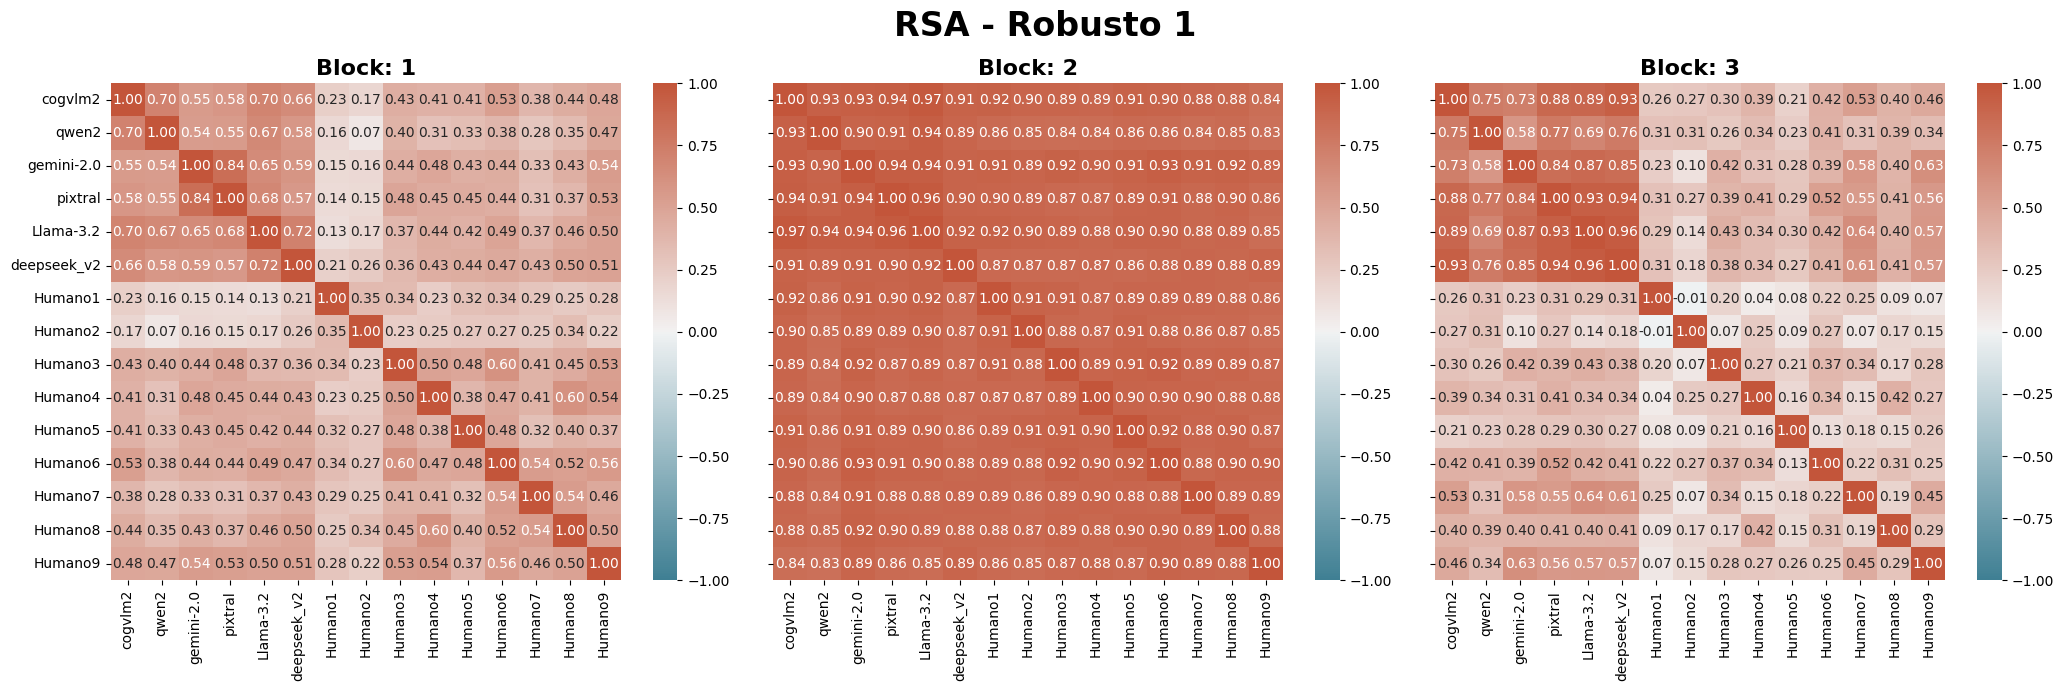

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
nrows = 1
ncols = len(blocks)
title = "RSA - Robusto 1"

fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 7 * nrows), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()
c = sns.diverging_palette(220, 20, as_cmap=True)

for block in sorted(df_r1_humans["BLOCK"].astype(int).unique()):
    c_ax = ax[block - 1]
    rsa_matrix = rsas[np.int64(block)]
    sns.heatmap(np.round(rsa_matrix,3), annot=True, xticklabels=agents, yticklabels=agents, cmap=c, ax=c_ax, vmin=-1, vmax=1, center=0, fmt=".2f")
    c_ax.set_title(f"Block: {block}", fontsize=16, weight="bold")
    
fig.suptitle(title, fontsize=24, weight="bold")
out_name = title.replace(" ", "_").replace(":","-").lower()
print(f"Saving RSA plot with title: {title} as rsa_output_{out_name}.png")
fig.tight_layout()
fig.savefig(f"./rsa_output_{out_name}.png", dpi=300)

In [15]:
def compute_rsa_pipeline(csv_path, model=None, agent_order=None, output_dir="./", title="RSA Analysis"):
    """
    Complete RSA pipeline: load CSV → process embeddings → compute gramians → plot RSA.
    
    Args:
        csv_path (str): Path to CSV file with columns: AGENT, ANSWER, BLOCK, VIDEO, QUESTION_NUM, REPETITION
        model (SentenceTransformer): Embedding model. If None, uses 'all-mpnet-base-v2'
        agent_order (list): List of agent names in preferred order. If None, uses order from CSV
        output_dir (str): Directory to save plots
        title (str): Title for the plot
    
    Returns:
        dict: {'rsas': RSA matrices by block, 'gramians': All gramian matrices, 'df': Processed dataframe}
    """
    import os
    from scipy.stats import pearsonr
    
    if model is None:
        model = sentence_transformers.SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Load and clean data
    df = pd.read_csv(csv_path, keep_default_na=False)
    df = df[df["ANSWER"] != "[Empty]"].reset_index(drop=True)
    
    # Separate humans and VLMs
    mask_human = df["AGENT"].str.contains("Humano", na=False)
    df_humans = df[mask_human]
    df_vlms = df[~mask_human]
    
    # Get default agent order from CSV if not provided
    if agent_order is None:
        human_agents = sorted(df_humans["AGENT"].unique().tolist())
        vlm_agents = df_vlms["AGENT"].unique().tolist()
        agent_order = vlm_agents + human_agents
    
    embedding_dim = model.encode([""], convert_to_tensor=True).shape[-1]
    gramians = {}
    embeds_by_block = {}
    
    # Process all agents
    for agent in agent_order:
        local_df = df[df["AGENT"] == agent].sort_values(by=["VIDEO", "QUESTION_NUM"]).reset_index(drop=True)
        
        if agent in df_humans["AGENT"].values:
            # Humans: one response per question
            responses = local_df["ANSWER"].astype(str).tolist()
            embeddings = extract_embeddings(responses)
            norm_embeddings = normalize_embeddings(embeddings)
            
            for block in local_df["BLOCK"].unique():
                idx = local_df[local_df["BLOCK"] == block].index
                embeds_by_block[(agent, block)] = norm_embeddings[idx]
        else:
            # VLMs: average multiple responses per question
            mean_embeddings = []
            groups = local_df.groupby(["VIDEO", "QUESTION_NUM"], sort=False)
            for _, group in groups:
                responses = group["ANSWER"].astype(str).tolist()
                embeds = extract_embeddings(responses) if responses else np.zeros((1, embedding_dim))
                norm_embeds = normalize_embeddings(embeds)
                avg_emb = np.mean(norm_embeds, axis=0)
                avg_emb = avg_emb / (np.linalg.norm(avg_emb) + 1e-8)
                mean_embeddings.append(avg_emb)
            
            mean_embeddings = np.array(mean_embeddings)
            local_df_unique = local_df.drop_duplicates(subset=["VIDEO", "QUESTION_NUM"], keep="first").reset_index(drop=True)
            
            for block in local_df_unique["BLOCK"].unique():
                idx = local_df_unique[local_df_unique["BLOCK"] == block].index
                embeds_by_block[(agent, block)] = mean_embeddings[idx]
        
        # Compute gramians
        for block in local_df["BLOCK"].unique():
            key = (agent, block)
            if key in embeds_by_block:
                gramians[key] = np.matmul(embeds_by_block[key], embeds_by_block[key].T)
    
    # Compute RSA for each block
    blocks = sorted(df["BLOCK"].unique())
    rsas = {}
    
    for block in blocks:
        rsa_matrix = np.zeros((len(agent_order), len(agent_order)))
        for i, agent_i in enumerate(agent_order):
            for j, agent_j in enumerate(agent_order):
                key_i = (agent_i, block)
                key_j = (agent_j, block)
                
                if key_i in gramians and key_j in gramians:
                    gram_i = gramians[key_i]
                    gram_j = gramians[key_j]
                    upper_i = gram_i[np.triu_indices_from(gram_i, k=1)]
                    upper_j = gram_j[np.triu_indices_from(gram_j, k=1)]
                    
                    if len(upper_i) > 0 and len(upper_j) > 0:
                        corr, _ = pearsonr(upper_i, upper_j)
                        rsa_matrix[i, j] = corr
                        rsa_matrix[j, i] = corr
        
        rsas[block] = rsa_matrix
    
    # Plot RSA heatmaps
    fig, ax = plt.subplots(1, len(blocks), figsize=(8*len(blocks), 7), sharex=True, sharey=True)
    ax = np.atleast_1d(ax).ravel()
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    
    for bid, block in enumerate(sorted(blocks)):
        sns.heatmap(np.round(rsas[block], 3), annot=True, xticklabels=agent_order, yticklabels=agent_order,
                    cmap=cmap, ax=ax[bid], vmin=-1, vmax=1, center=0, fmt=".2f", cbar=(bid == len(blocks)-1))
        ax[bid].set_title(f"Block {block}", fontsize=14, weight="bold")
    
    fig.suptitle(title, fontsize=18, weight="bold")
    fig.tight_layout()
    out_file = os.path.join(output_dir, f"rsa_{title.replace(' ', '_').lower()}.png")
    fig.savefig(out_file, dpi=300)
    print(f"✓ Saved: {out_file}")
    plt.show()
    
    return {'rsas': rsas, 'gramians': gramians, 'df': df, 'agent_order': agent_order}


✓ Saved: ./rsa_rsa_-_robusto_1.png


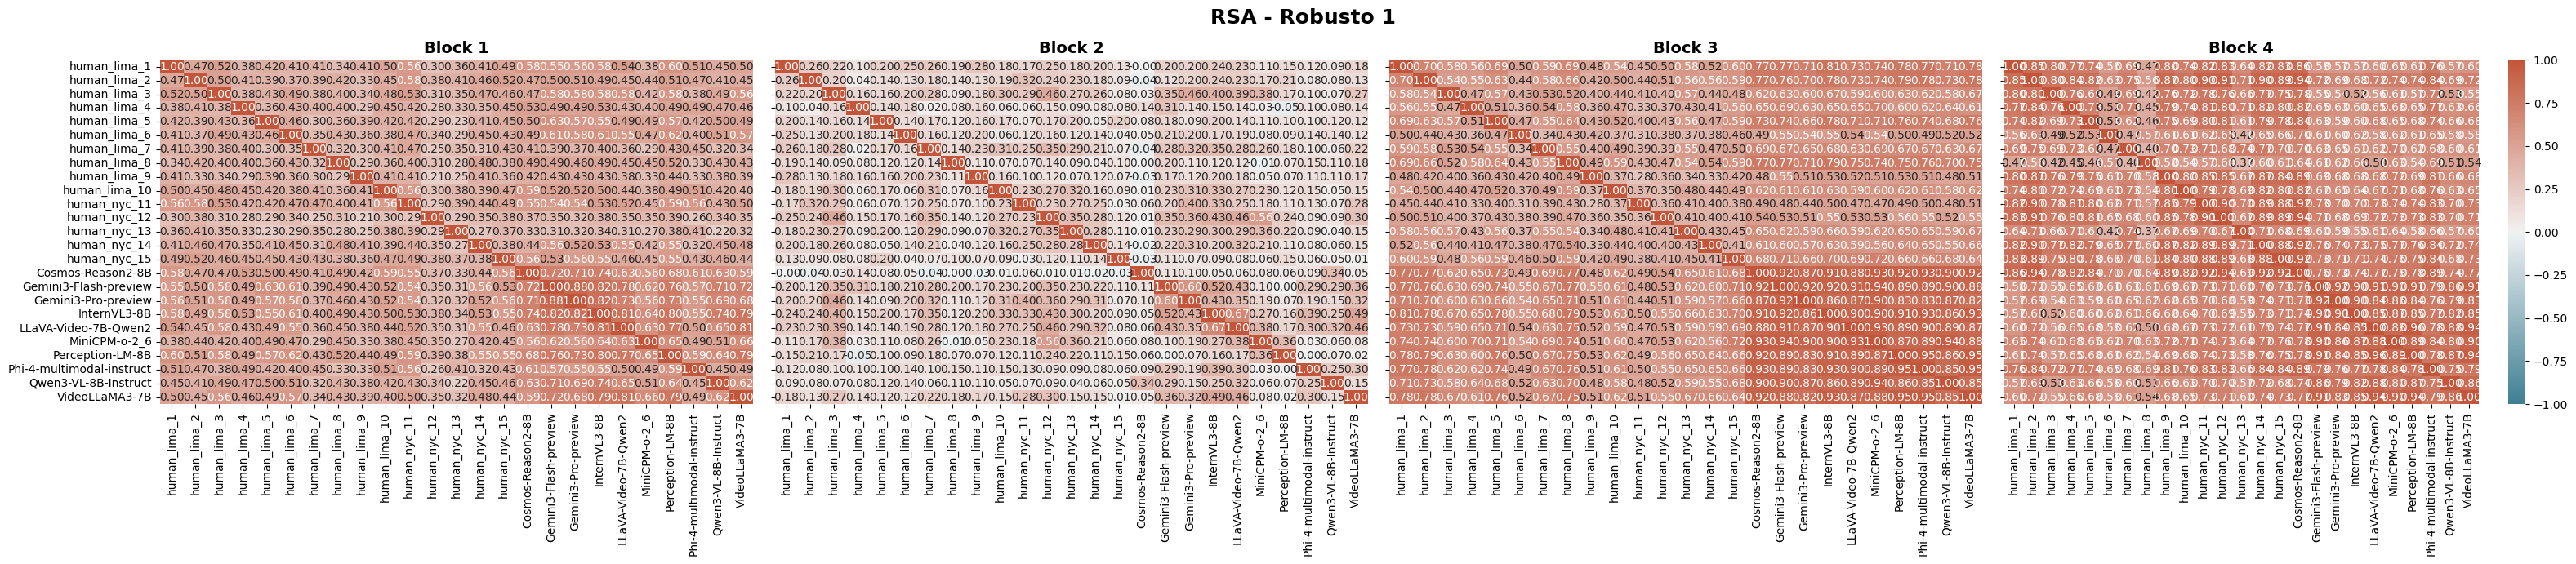

In [ ]:
result = compute_rsa_pipeline(
    csv_path="./data/r2_cleaned.csv",
    title="RSA - Robusto 2"
)

In [1]:
!nvidia-smi

def free_gpu_memory():
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("GPU memory freed.")
    else:
        print("No GPU available.")
free_gpu_memory()

Wed Feb 25 16:03:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.04              Driver Version: 577.00         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 ...    On  |   00000000:06:00.0  On |                  N/A |
| 68%   52C    P2             27W /  100W |    2070MiB /   4096MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----